# Imports

In [9]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
%load_ext autoreload
%autoreload 2

import imp
import sys
import random
import networkx as nx
import osmnx as ox
import rasterio
import numpy as np
import pandas as pd
import matplotlib.cm as cm 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from collections import Counter

import graph_util   
import plotting

#NOTE by default OSM doesnt call the bicycle and cycleway info for performance reasons  
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["bicycle", "cycleway"]

path, pedestrian

# Network setup

In [10]:

#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
LOCATION = "Malta (island)"
G_bike = ox.graph.graph_from_place(LOCATION, network_type="bike", simplify=True, retain_all=True)
G_drive = ox.graph.graph_from_place(LOCATION, network_type="drive", simplify=True, retain_all=True)

In [11]:
highway_priority = [
        "track",           # Lowest priority - often just access roads
        "service", 
        "path",
        "unclassified",
        "residential",
        "living_street", 
        "tertiary",
        "secondary",
        "primary",
        "trunk",
        "cycleway"         # Highest priority - dedicated cycling infrastructure
    ]

def select_primary_highway(highway_list:list[str]|str, priority_order:list) -> str:
    """Select the highest priority highway type from a list."""
    if not isinstance(highway_list, list):
        return highway_list
    
    # Find highest priority highway type
    best_highway = highway_list[0]  # fallback
    best_priority = -1
    
    for highway in highway_list:
        try:
            priority = priority_order.index(highway)
            if priority > best_priority:
                best_priority = priority
                best_highway = highway
        except ValueError:
            # Highway type not in priority list, use as fallback
            continue
    
    return best_highway

Highway type counts:
residential: 26546
service: 15816
track: 11086
unclassified: 6636
tertiary: 5266
secondary: 4339
path: 2844
primary: 1627
trunk: 1381
living_street: 1040
pedestrian: 502
cycleway: 320
trunk_link: 207
secondary_link: 65
tertiary_link: 43
primary_link: 39
busway: 1
-------
bikeway classification type counts:
None: 75558
yes: 1868
designated: 316
permissive: 14
private: 2
------
cycleway type counts:
None: 75558
yes: 1868
designated: 316
permissive: 14
private: 2


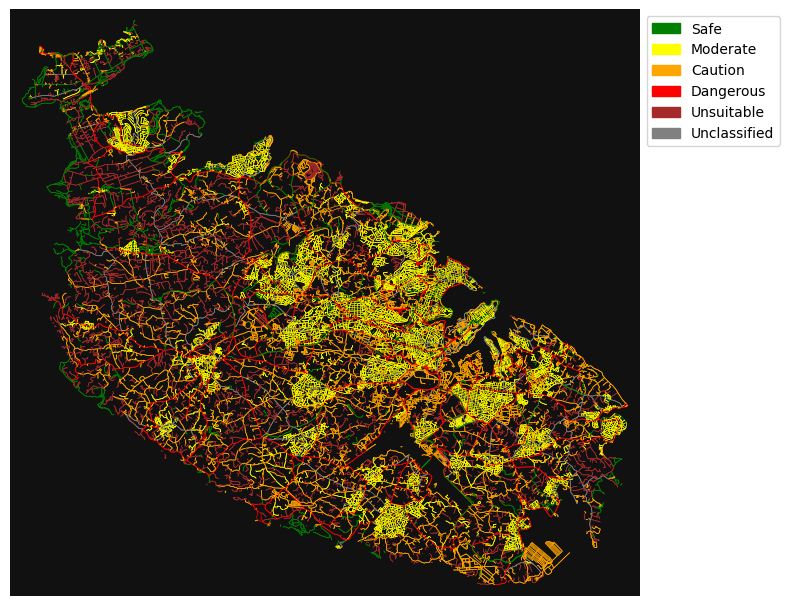

In [ ]:
#TODO remove tracks from the network

#NOTE  retain_all to get all nodes even if not connected to the main network
#fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)
edge_colors = []
highway_counts = Counter()
bikeway_counts = Counter()
cycleway_counts = Counter()
for u, v, k, data in G_bike.edges(keys=True, data=True):
    once = False

    highway = data.get("highway")
    highway = select_primary_highway(highway, highway_priority)

    bicycle = data.get("bicycle")
    bicycle = select_primary_highway(bicycle, highway_priority)

    cycleway = data.get("cycleway")
    cycleway = select_primary_highway(bicycle, highway_priority)

    #print(f"highway: {highway},\t\t bicycle: {bicycle},\t\t cycleway: {cycleway}")

    # Override dangerous roads if bicycle=yes,
    # example kappara junction there is protected cycle lane on the main road 
    match(bicycle):
        case "designated": data["safety"] = "safe"
        case "yes": data["safety"] = "safe"
        case _: data["safety"] = graph_util.highway_to_safety_map.get(highway, "unclassified") 
    
    colour = graph_util.safety_to_color_map.get(data["safety"])
    data["risk_factor"] = graph_util.safety_to_risk_factor_map.get(data["safety"])
    edge_colors.append(colour)

    highway_counts[highway] += 1
    bikeway_counts[bicycle] += 1
    cycleway_counts[cycleway] += 1

print("Highway type counts:")
for highway_type, count in highway_counts.most_common():
    print(f"{highway_type}: {count}")

print("-------")
print("bikeway classification type counts:")
for bikeway_type, count in bikeway_counts.most_common():
    print(f"{bikeway_type}: {count}")

print("------")
print("cycleway type counts:")
for cycleway_type, count in cycleway_counts.most_common():
    print(f"{cycleway_type}: {count}")


plotting.plot_road_classification(G_bike, edge_colors)

## Edge Data

In [13]:
G_bike = ox.elevation.add_node_elevations_raster(G_bike, "../Data/rasters_COP30.tif")
G_bike = ox.elevation.add_edge_grades(G_bike, add_absolute=True)

In [14]:
# what sized area does our network cover in square meters?
G_bike_proj = ox.projection.project_graph(G_bike) #convert lat/long coordinates into meters
bike_nodes_proj = ox.convert.graph_to_gdfs(G_bike_proj, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(G_bike_proj, area=graph_area_m, clean_int_tol=15)

In [15]:
# Find all unique edge attributes
all_edge_attrs = set()
for u, v, k, data in G_bike.edges(keys=True, data=True):
    all_edge_attrs.update(data.keys())

print("Available edge attributes:")
for attr in sorted(all_edge_attrs):
    print(f"  - {attr}")

Available edge attributes:
  - access
  - area
  - bicycle
  - bridge
  - cycleway
  - geometry
  - grade
  - grade_abs
  - highway
  - junction
  - lanes
  - length
  - maxspeed
  - name
  - oneway
  - osmid
  - ref
  - reversed
  - risk_factor
  - safety
  - service
  - tunnel
  - width


$$\text{bike\_cost} = \text{length} \times (\alpha\text{gradient} + \beta\text{risk})$$

In [ ]:
"""
u - Source node ID (starting point of the edge)
v - Target node ID (ending point of the edge)
k - Edge key (for multigraphs where multiple edges can exist between the same nodes)
data - Dictionary containing all the edge attributes/properties"""

#Since continuity will be used a global evaluation metric there is no need to have it be a weight in the pair wise edges

def calc_bike_cost(G_bike, alpha, beta):
    # Project the graph for meters distances instead of angles
    G_bike_proj = ox.projection.project_graph(G_bike)

    for u, v, k, data in G_bike_proj.edges(keys=True, data=True):
        #alpha*data["grade_abs"]
        #NOTE absolute length was used instead of normalised length to keep the true magnitude ensures realistic, additive path costs rather than distorting them through arbitrary scaling.
        data["bike_cost"] = data["length"] * (beta*data["risk_factor"])
        pass


# First calculate bike costs
calc_bike_cost(G_bike, alpha=0.1, beta=1.0)  # Adjust alpha/beta values as needed


what_im_plotting = "bike_cost"

# Get edge colors based on bike_cost
edge_colors = ox.plot.get_edge_colors_by_attr(G_bike, what_im_plotting, cmap="viridis")
grade_abs_values = [data.get(what_im_plotting, 0) for u, v, k, data in G_bike.edges(keys=True, data=True) if data.get(what_im_plotting) is not None]
min_grade = min(grade_abs_values)
max_grade = max(grade_abs_values)

# Plot the network
fig, ax = ox.plot.plot_graph(G_bike, node_size=0, edge_color=edge_colors, edge_linewidth=0.5, show=False, close=False)
# Create and add colorbar
sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=min_grade, vmax=max_grade))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label(what_im_plotting, rotation=270, labelpad=20)
plt.tight_layout()
plt.show()

ValueError: There are no attribute values.

In [ ]:
edges = ox.convert.graph_to_gdfs(G_bike, nodes=False)
edges.groupby("risk_factor")["bike_cost"].mean()

# Global Metrics

In [ ]:
"""def calc_global_metrics(G, k=1000):
    #full centrality is O(n^3), k is instead used to approximate
    #TODO need to handle isolated components?
    G_proj = ox.project_graph(G)

    #Betweenness centrality - key connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_proj, weight="length", normalized=True, k=k)
    between_cent_values = list(edge_between_cent.values())
    between_cent_sum = sum(between_cent_values)
    #nx.set_edge_attributes(G, edge_between_cent, "betweenness")

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_proj, distance="length")
    close_cent_values = list(node_close_cent.values())
    close_cent_sum = sum(close_cent_values)
    #nx.set_node_attributes(G, node_close_cent, "closeness")"""

In [ ]:
# Add this to your calc_global_metrics function:
def calc_global_metrics(G, k=1000):
    """Calculate comprehensive centrality metrics for cycling network assessment"""
    #NOTE full centrality is O(n^3), k is instead used to approximate
    #TODO need to handle isolated components?
    G_proj = ox.project_graph(G)
    
    # Edge betweenness centrality - connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_proj, weight="length_m", normalized=True, k=k)
    nx.set_edge_attributes(G, edge_between_cent, "edge_betweenness")

    # Node centrality - critical intersections and accessibility
    node_between_cent = nx.betweenness_centrality(G_proj, weight="length_m", normalized=True, k=k)
    nx.set_node_attributes(G, node_between_cent, "node_betweenness") 

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_proj, distance="length_m")
    nx.set_node_attributes(G, node_close_cent, "closeness")
        
    return edge_between_cent, node_between_cent, node_close_cent